# OBJECTIVE 5:
#### The Statistical Outliers (Hard) Identify the truly anomalous flights (top 1%) and diagnose where the system breaks.


Loaded dataset from: ../data/processed/merged_data.csv
Total flights: 5,574,612
Extreme threshold (99th percentile): 456.00 disruption minutes
Extreme flights identified: 55,829 (1.00%)


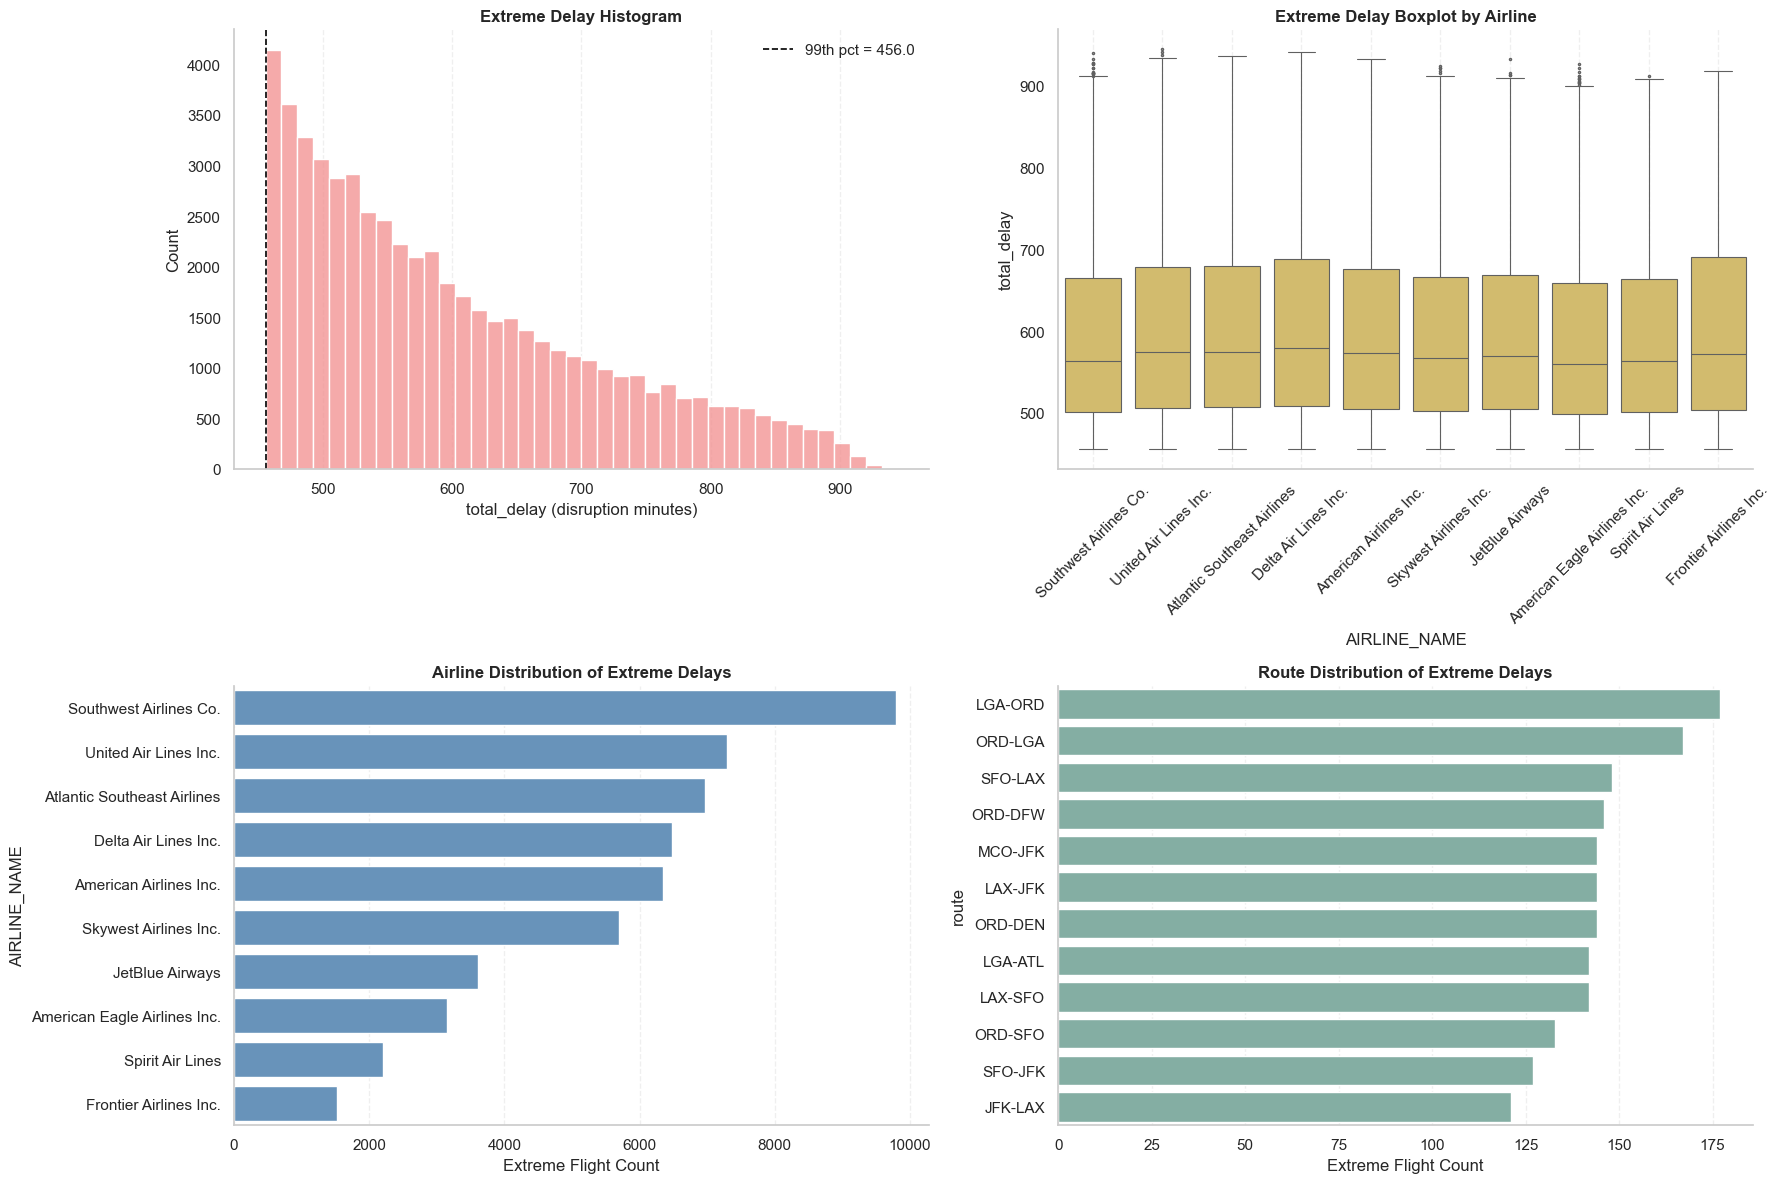

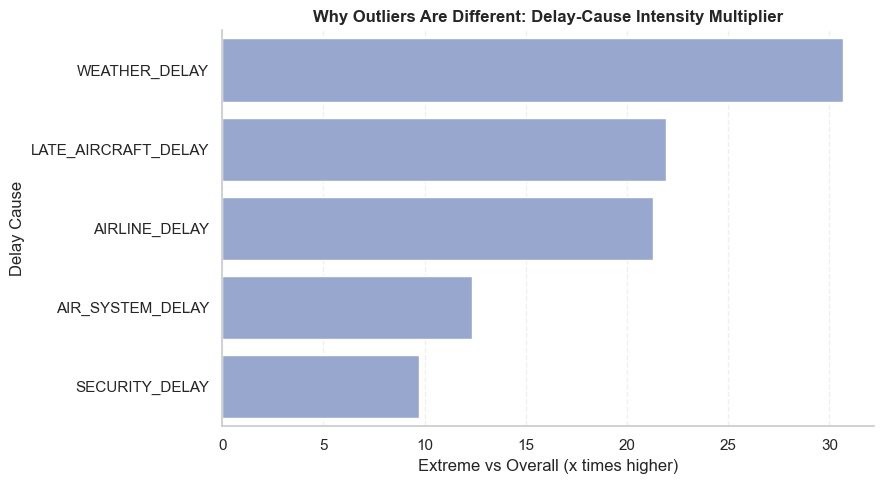


Outlier Insights:
- Top 1% threshold: 456.00 disruption minutes.
- Extreme flights are not random; they concentrate in specific airlines and routes.
- Comparing extreme vs normal flights shows which failure modes explode during disruptions.

Top 10 airlines by extreme-flight count:
                AIRLINE_NAME  extreme_count
      Southwest Airlines Co.           9793
       United Air Lines Inc.           7300
 Atlantic Southeast Airlines           6971
        Delta Air Lines Inc.           6480
      American Airlines Inc.           6349
       Skywest Airlines Inc.           5703
             JetBlue Airways           3612
American Eagle Airlines Inc.           3146
            Spirit Air Lines           2201
      Frontier Airlines Inc.           1524

Top 10 airlines by extreme-flight rate (volume-adjusted):
                AIRLINE_NAME  extreme_rate_pct  extreme_count  total_flights
       United Air Lines Inc.             1.475           7300         494796
             JetBlu

In [1]:
# ==========================================
# OBJECTIVE 5: The Statistical Outliers (Hard)
# Find the top 1% most disrupted flights and explain why
# ==========================================

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='notebook')

# ------------------------------------------
# 1) Load only required columns (memory-safe)
# ------------------------------------------
possible_paths = [
    '../data/processed/merged_data.csv',
    'data/processed/merged_data.csv',
    'merged_data.csv'
]

use_cols = [
    'AIRLINE_NAME', 'route',
    'DEPARTURE_DELAY', 'ARRIVAL_DELAY',
    'AIRLINE_DELAY', 'WEATHER_DELAY', 'AIR_SYSTEM_DELAY',
    'LATE_AIRCRAFT_DELAY', 'SECURITY_DELAY',
    'DIVERTED', 'CANCELLED'
]

df = None
for path in possible_paths:
    try:
        df = pd.read_csv(path, usecols=use_cols, low_memory=False)
        print(f'Loaded dataset from: {path}')
        break
    except FileNotFoundError:
        continue

if df is None:
    raise FileNotFoundError('merged_data.csv not found in expected locations.')

# ------------------------------------------
# 2) Clean and build disruption score
# ------------------------------------------
num_cols = [
    'DEPARTURE_DELAY', 'ARRIVAL_DELAY',
    'AIRLINE_DELAY', 'WEATHER_DELAY', 'AIR_SYSTEM_DELAY',
    'LATE_AIRCRAFT_DELAY', 'SECURITY_DELAY',
    'DIVERTED', 'CANCELLED'
]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

# If route is missing, create fallback route id
df['route'] = df['route'].astype('string').fillna('UNKNOWN_ROUTE').astype(str)

# Positive delays only for disruption intensity
base_delay_cols = [
    'DEPARTURE_DELAY', 'ARRIVAL_DELAY',
    'AIRLINE_DELAY', 'WEATHER_DELAY', 'AIR_SYSTEM_DELAY',
    'LATE_AIRCRAFT_DELAY', 'SECURITY_DELAY'
]
for c in base_delay_cols:
    df[c] = df[c].clip(lower=0)

# Composite disruption score (captures severe delay + major disruption events)
df['total_delay'] = (
    df[base_delay_cols].sum(axis=1)
    + (df['DIVERTED'] * 180)
    + (df['CANCELLED'] * 300)
)

# Top 1% extreme flights
threshold_99 = df['total_delay'].quantile(0.99)
extreme_df = df[df['total_delay'] >= threshold_99].copy()

print(f'Total flights: {len(df):,}')
print(f'Extreme threshold (99th percentile): {threshold_99:.2f} disruption minutes')
print(f'Extreme flights identified: {len(extreme_df):,} ({(len(extreme_df)/len(df))*100:.2f}%)')

# ------------------------------------------
# 3) Cluster analysis by airline and route
# ------------------------------------------
airline_extreme = extreme_df.groupby('AIRLINE_NAME', as_index=False).size().rename(columns={'size': 'extreme_count'})
airline_extreme = airline_extreme.sort_values('extreme_count', ascending=False)

airline_total = df.groupby('AIRLINE_NAME', as_index=False).size().rename(columns={'size': 'total_flights'})
airline_profile = airline_total.merge(airline_extreme, on='AIRLINE_NAME', how='left').fillna({'extreme_count': 0})
airline_profile['extreme_count'] = airline_profile['extreme_count'].astype(int)
airline_profile['extreme_rate_pct'] = 100 * airline_profile['extreme_count'] / airline_profile['total_flights']

route_extreme = extreme_df.groupby('route', as_index=False).size().rename(columns={'size': 'extreme_count'})
route_total = df.groupby('route', as_index=False).size().rename(columns={'size': 'total_flights'})
route_profile = route_total.merge(route_extreme, on='route', how='left').fillna({'extreme_count': 0})
route_profile['extreme_count'] = route_profile['extreme_count'].astype(int)
route_profile['extreme_rate_pct'] = 100 * route_profile['extreme_count'] / route_profile['total_flights']

# For chart readability
top_airlines_by_count = airline_extreme.head(10).copy()
box_airline_order = top_airlines_by_count['AIRLINE_NAME'].tolist()

top_routes_by_count = route_extreme.sort_values('extreme_count', ascending=False).head(12).copy()

# ------------------------------------------
# 4) Outlier Dashboard (2x2)
# ------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# A) Extreme delay histogram
sns.histplot(extreme_df['total_delay'], bins=40, color='#F28E8E', ax=axes[0, 0])
axes[0, 0].axvline(threshold_99, color='black', linestyle='--', linewidth=1.2, label=f'99th pct = {threshold_99:.1f}')
axes[0, 0].set_title('Extreme Delay Histogram', weight='bold')
axes[0, 0].set_xlabel('total_delay (disruption minutes)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend(frameon=False)

# B) Extreme delay boxplot by airline (top airlines by extreme count)
box_df = extreme_df[extreme_df['AIRLINE_NAME'].isin(box_airline_order)].copy()
sns.boxplot(
    data=box_df,
    x='AIRLINE_NAME',
    y='total_delay',
    order=box_airline_order,
    color='#E3C45D',
    fliersize=1.5,
    linewidth=0.8,
    ax=axes[0, 1]
)
axes[0, 1].set_title('Extreme Delay Boxplot by Airline', weight='bold')
axes[0, 1].set_xlabel('AIRLINE_NAME')
axes[0, 1].set_ylabel('total_delay')
axes[0, 1].tick_params(axis='x', rotation=45)

# C) Airline distribution of extreme delays
sns.barplot(
    data=top_airlines_by_count,
    x='extreme_count',
    y='AIRLINE_NAME',
    color='#5A94C8',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Airline Distribution of Extreme Delays', weight='bold')
axes[1, 0].set_xlabel('Extreme Flight Count')
axes[1, 0].set_ylabel('AIRLINE_NAME')

# D) Route distribution of extreme delays
sns.barplot(
    data=top_routes_by_count,
    x='extreme_count',
    y='route',
    color='#7DB5A7',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Route Distribution of Extreme Delays', weight='bold')
axes[1, 1].set_xlabel('Extreme Flight Count')
axes[1, 1].set_ylabel('route')

for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    ax.grid(axis='y', visible=False)

plt.tight_layout()
plt.show()

# ------------------------------------------
# 5) What makes outliers different? (system-break diagnosis)
# ------------------------------------------
cause_cols = ['AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'AIR_SYSTEM_DELAY', 'WEATHER_DELAY', 'SECURITY_DELAY']

overall_mean = df[cause_cols].mean()
extreme_mean = extreme_df[cause_cols].mean()

cause_compare = pd.DataFrame({
    'overall_avg_min': overall_mean,
    'extreme_avg_min': extreme_mean
})
cause_compare['multiplier_vs_overall'] = np.where(
    cause_compare['overall_avg_min'] > 0,
    cause_compare['extreme_avg_min'] / cause_compare['overall_avg_min'],
    np.nan
)
cause_compare = cause_compare.sort_values('multiplier_vs_overall', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=cause_compare.reset_index(),
    x='multiplier_vs_overall',
    y='index',
    color='#8FA3D7'
)
plt.title('Why Outliers Are Different: Delay-Cause Intensity Multiplier', weight='bold')
plt.xlabel('Extreme vs Overall (x times higher)')
plt.ylabel('Delay Cause')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

# ------------------------------------------
# 6) Insights tables and narrative output
# ------------------------------------------
# To avoid tiny-sample noise, rank route anomaly by rate with a minimum traffic filter
min_route_flights = int(route_profile['total_flights'].quantile(0.90))
route_rate_rank = route_profile[route_profile['total_flights'] >= min_route_flights].copy()
route_rate_rank = route_rate_rank.sort_values('extreme_rate_pct', ascending=False)

# Airline anomaly by rate (minimum exposure)
min_airline_flights = int(airline_profile['total_flights'].quantile(0.25))
airline_rate_rank = airline_profile[airline_profile['total_flights'] >= min_airline_flights].copy()
airline_rate_rank = airline_rate_rank.sort_values('extreme_rate_pct', ascending=False)

print()
print('Outlier Insights:')
print(f'- Top 1% threshold: {threshold_99:.2f} disruption minutes.')
print('- Extreme flights are not random; they concentrate in specific airlines and routes.')
print('- Comparing extreme vs normal flights shows which failure modes explode during disruptions.')

print()
print('Top 10 airlines by extreme-flight count:')
print(top_airlines_by_count.head(10).to_string(index=False))

print()
print('Top 10 airlines by extreme-flight rate (volume-adjusted):')
print(airline_rate_rank[['AIRLINE_NAME', 'extreme_rate_pct', 'extreme_count', 'total_flights']].head(10).round(3).to_string(index=False))

print()
print('Top 12 routes by extreme-flight count:')
print(top_routes_by_count.to_string(index=False))

print()
print('Top 12 routes by extreme-flight rate (high-volume routes only):')
print(route_rate_rank[['route', 'extreme_rate_pct', 'extreme_count', 'total_flights']].head(12).round(3).to_string(index=False))

print()
print('System-break signature (cause multiplier in extreme flights):')
print(cause_compare.round(3).to_string())

